In [2]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import xarray as xr


from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots, compare_temporal_profiles
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR, SIMUS_COLORS_DICT

/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [3]:
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')['pr'].values
print(clim)

[[0.14528096 0.14601318 0.14676182 ... 0.14334319 0.14392168 0.14457691]
 [0.16509808 0.16596339 0.16774778 ... 0.16128826 0.16213806 0.16384732]
 [0.18879832 0.18534831 0.18309616 ... 0.19843951 0.19585846 0.192707  ]
 ...
 [0.78236447 0.77662932 0.76906599 ... 0.79233282 0.79020525 0.78709357]
 [0.72186913 0.72854202 0.73440802 ... 0.70158798 0.70907211 0.71492045]
 [0.47602938 0.47525781 0.47467665 ... 0.47822815 0.47728524 0.47668551]]


In [38]:
var_name = 'pr'

true = xr.open_dataset( DATASET_DIR / 'MPI-ESM1-2-LR/annual/outputs_ssp245.nc').mean('member')
lats = true.lat.values
t = true.time.values
y = true['pr'].values - clim

c3 = xr.open_dataset(PREDICTIONS_DIR / 'MPI-ESM1-2-LR/annual/exp5/MPI-ESM1-2-LR_annual_exp5_ssp370_pr_cnn-lstm_seq5_mem30_epoch30.nc')['pr'].values - clim
c4 = xr.open_dataset(PREDICTIONS_DIR / 'MPI-ESM1-2-LR/annual/exp7/MPI-ESM1-2-LR_annual_exp7_ssp370_pr_cnn-lstm_seq5_mem30_epoch30.nc')['pr'].values - clim
c5 = xr.open_dataset(PREDICTIONS_DIR / 'MPI-ESM1-2-LR/annual/exp8/MPI-ESM1-2-LR_annual_exp8_ssp370_pr_cnn-lstm_seq5_mem30_epoch30.nc')['pr'].values - clim
c6 = xr.open_dataset(PREDICTIONS_DIR / 'MPI-ESM1-2-LR/annual/exp9/MPI-ESM1-2-LR_annual_exp9_ssp245_pr_cnn-lstm_seq5_mem30_epoch30.nc')['pr'].values - clim


print(lats.shape, t.shape, c3.shape, c4.shape, c5.shape)

y_hat_dict = {'exp9': [c6[run] for run in range(c6.shape[0])]}

save_dir = GRAPHS_DIR /'tests/'


(96,) (86,) (10, 86, 96, 192) (10, 86, 96, 192) (10, 86, 96, 192)


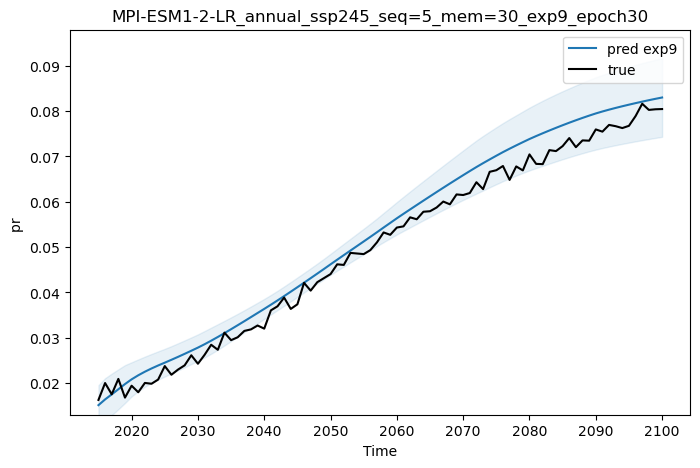

In [39]:
for key, value in y_hat_dict.items():
    mini_dict = {key:value}
    title = f'MPI-ESM1-2-LR_annual_ssp245_seq=5_mem=30_{key}_epoch30'
    compare_temporal_profiles(y, mini_dict, t, var_name, lats, point=None, window_size=None, config_plots=None, title=title, save_dir=save_dir)

evalllll
['ssp370_hist-GHG']
ssp370_hist-GHG
(96, 192)
(96, 192)
(96, 192)
(96, 192)


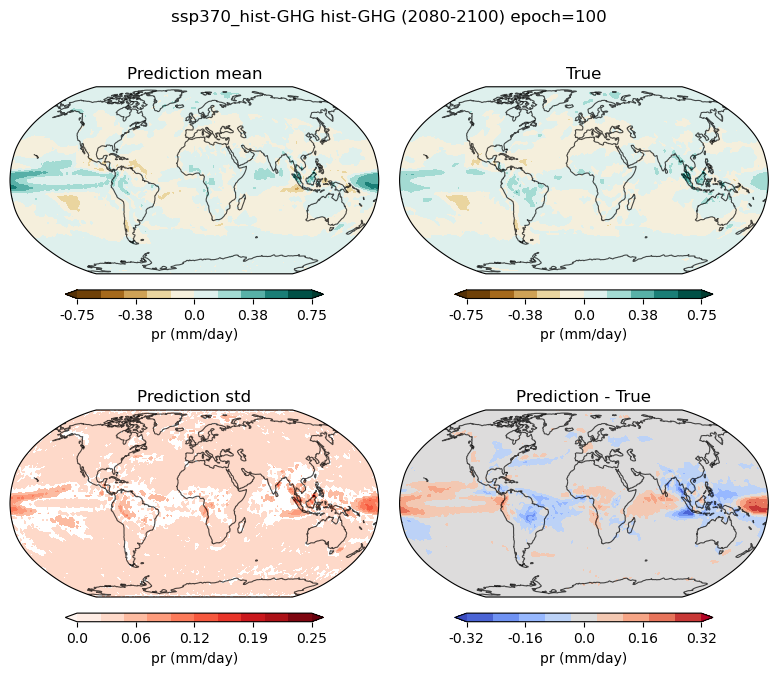

In [22]:
with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)
    
config_plots['pr']['lim']['mean_error'] = [-0.32, 0.32]
config_plots['pr']['lim']['values'] = [-0.75, 0.75]
config_plots['pr']['lim']['std'] = [0, 0.25]


#best = xr.open_dataset('/gpfs-calypso/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp1/MPI-ESM1-2-LR_annual_exp1_ssp245_pr_cnn-lstm_seq5_mem50_sub1.nc').sel(time=slice('2080', '2100'))['pr'].values - clim

eval_func = EvaluationPlots(config_plots=config_plots,
                                        simulation_name='hist-GHG',var_name=var_name)
print(list(y_hat_dict.keys()))
for i, y_hat in enumerate([c5]):
    test_name = list(y_hat_dict.keys())[i]
    print(test_name)
    save_path = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual/MPI-ESM1-2-LR_annual_hist-GHG_diff_maps_pr_seq5_mem30_{test_name}.png'       
    #save_path = None
    eval_func.plot_diff_maps(y, 
                            y_hat.mean(axis=0), 
                            y_hat.std(axis=0), 
                            title=f'{test_name} hist-GHG (2080-2100) epoch=100',
                             no_limits=False,
                            save_path=save_path)

In [ ]:
c5 = c5.mean(axis=1)
mean_error = 

## Cross validation

In [3]:
simu_dict = {'ssp126': 'SSP1-2.6', 
              'ssp245': 'SSP2-4.5', 
              'ssp370':'SSP3-7.0', 
              'ssp585': 'SSP5-8.5'}
def plot_mean_std_simulations(files_dict,
                                var_name,
                                colors_dict=None,
                                vmin=None,
                                vmax=None,
                                time_res = 'Y',
                                title=None,
                                save_path=None):

    
    plt.figure(figsize=(6, 5)) 
    for simu, files in files_dict.items():
        if isinstance(files, str) or isinstance(files, Path):
            files = [files]
        color = colors_dict[simu] if colors_dict else None
        time = []
        mean = []
        std = []
        for file in files:
            if time_res == 'm':
                ds = xr.open_dataset(file, chunks= {'time':12})
                ds = dataset_xr_formatting(ds, original_time_format = "%Y%m")
                ds = ds[var_name].groupby('time.year').mean('time').rename({'year': 'time'})
        
            else:
                ds = xr.open_dataset(file)
                ds = dataset_xr_formatting(ds, original_time_format = "%Y")
                ds = ds[var_name]
            
            unit = ds.attrs["units"]       
            ds = ds - clim[var_name]
            ds = weighted_global_mean(ds)

            time.append(ds.time.values)
            if 'run' in ds.dims:
                mean.append(ds.mean('run').values)
                std.append(ds.std('run').values)
            else:
                mean.append(ds.values)
                std.append(np.zeros_like(ds.values))
            ds.close()
        time = np.concatenate(time)
        mean = np.concatenate(mean)
        std = np.concatenate(std)
        if simu == 'ssp126':
            plt.plot(time, mean, label='Predictions mean', color=color, linestyle = '--', linewidth=1, alpha=0.6)
            plt.fill_between(time, mean - std, mean + std, alpha=0.2, color=color, label ='Predictions 2*std')
        else:
            plt.plot(time, mean, color=color, linestyle = '--', linewidth=1, alpha=0.6)
            plt.fill_between(time, mean - std, mean + std, alpha=0.2, color=color)

        # Add true simulation
        ds_true = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc')[var_name].mean('member') - clim[var_name]
        ds_true = weighted_global_mean(ds_true)
        simu_name = simu_dict[simu]
        plt.plot(time, ds_true.values , label=simu_name, color=color, linewidth=2)

    plt.grid(axis='y', alpha = 0.5)
    plt.ylabel(f'{var_name} {unit}')
    plt.ylim(vmin, vmax)
    plt.legend(loc ='upper left')
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)

{'ssp126': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp2/MPI-ESM1-2-LR_annual_exp2_ssp126_pr_cnn-lstm_seq5_mem50_sub1.nc', 'ssp245': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp1/MPI-ESM1-2-LR_annual_exp1_ssp245_pr_cnn-lstm_seq5_mem50_sub1.nc', 'ssp370': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp3/MPI-ESM1-2-LR_annual_exp3_ssp370_pr_cnn-lstm_seq5_mem50_sub1.nc', 'ssp585': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp4/MPI-ESM1-2-LR_annual_exp4_ssp585_pr_cnn-lstm_seq5_mem50_sub1.nc'}


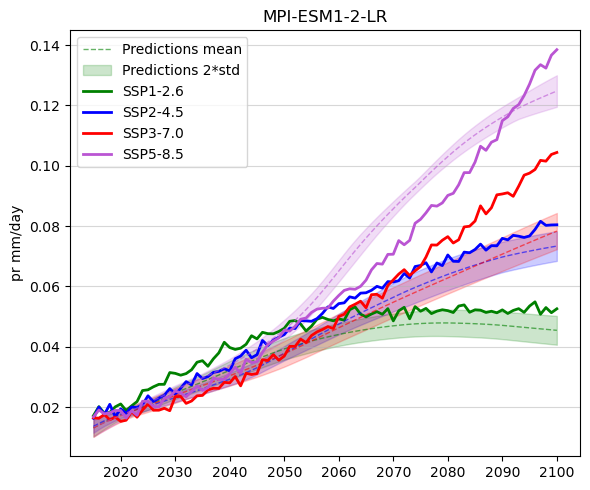

In [4]:
simus = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
files_dict = {}
colors_dict = {'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
exp_dict = {'ssp126': 'exp2', 
              'ssp245': 'exp1', 
              'ssp370':'exp3', 
              'ssp585': 'exp4'}
vmin = {'tas': None, 'pr': None}
vmax = {'tas': None, 'pr': None}
for var_name in ['pr']:
    for simu in simus:
        files_dict[simu] = glob.glob(str(PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/*/*{simu}_{var_name}*seq5_*.nc'))[0]
    plot_mean_std_simulations(files_dict,
                              var_name=var_name,
                              colors_dict = colors_dict,
                              title='MPI-ESM1-2-LR',
                              vmin=vmin[var_name],
                              vmax=vmax[var_name],
                              save_path= GRAPHS_DIR / f'runs/MPI-ESM1-2-LR/annual/{var_name}_temporal_profiles_cross_validation.png'
                              )
print(files_dict)

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)
evalllll
(96, 192)
(96, 192)
(96, 192)


KeyboardInterrupt: 

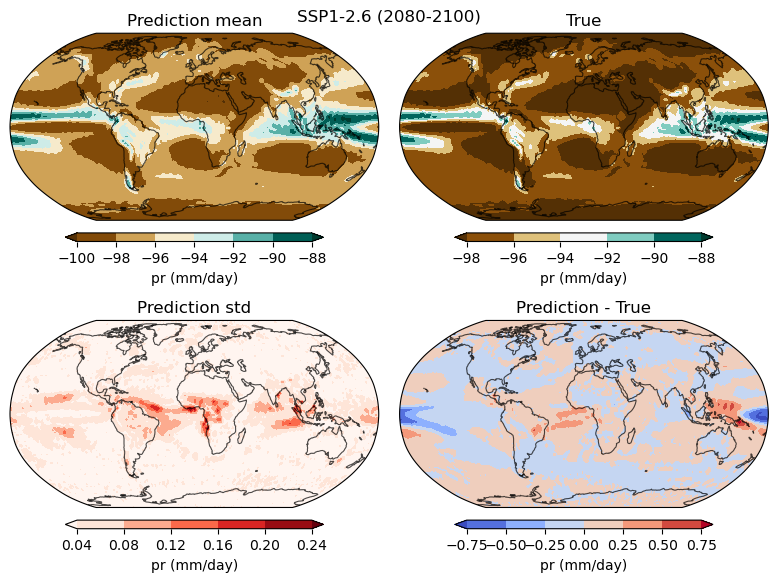

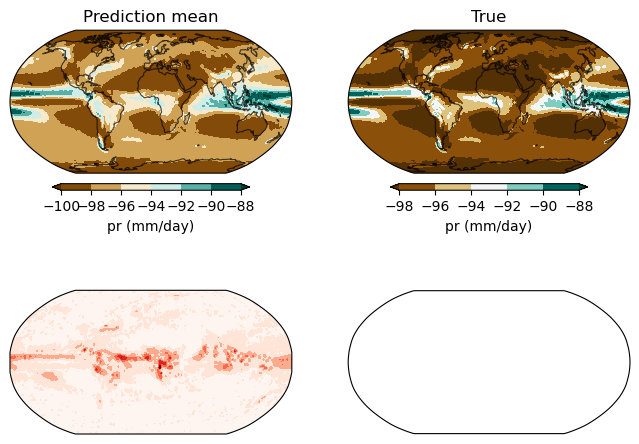

In [16]:

with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)
    
config_plots['tas']['lim']['mean_error'] = [-2,2]
config_plots['tas']['lim']['values'] = [0, 14]
config_plots['pr']['lim']['std'] = [0, 0.6]
config_plots['pr']['lim']['mean_error'] = [-1.2,1.2]
config_plots['pr']['lim']['values'] = [-2.4, 2.4]
config_plots['pr']['lim']['std'] = [0, 0.25]

for var_name in ['pr']:
    for simu in simus:
        simu_name = simu_dict[simu]
        exp = exp_dict[simu]
        if var_name == 'pr':
            test_name = 'seq5_mem50'
        elif var_name == 'tas':
            test_name = 'seq10_mem30'
        files_dict[simu] = glob.glob(str(PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/*/*{simu}_{var_name}*{test_name}*.nc'))[0]
       
        eval_func = EvaluationPlots(config_plots=config_plots,
                                        simulation_name=simu,
                                        var_name=var_name)
        y = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc')[var_name].mean('member').sel(time=slice('2080', '2100')) - clim[var_name] / clim[var_name] *100
        y_hat = xr.open_dataset(files_dict[simu])[var_name].sel(time=slice('2080', '2100')) - clim[var_name] / clim[var_name] * 100
        
        save_path = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual/{exp}/MPI-ESM1-2-LR_annual_{exp}_{simu}_relative_diff_maps_{var_name}_{test_name}.png'                                                                                                             
        eval_func.plot_diff_maps(y.values, 
                                y_hat.mean('run').values, 
                                y_hat.std('run').values, 
                                title=f'{simu_name} (2080-2100)',
                                 no_limits=True,
                                save_path=save_path)